In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import umap

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from time import time

seed = 42

## Dataset

In [2]:
df = pd.read_csv("TUANDROMD.csv", sep=',')
pd.options.display.max_columns = None


display(df)

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,ACCESS_PROVIDER,ACCESS_SERVICE,ACCESS_SHARED_DATA,ACCESS_SUPERUSER,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,activityCalled,ACTIVITY_RECOGNITION,ACCOUNT_MANAGER,ADD_VOICEMAIL,ANT,ANT_ADMIN,AUTHENTICATE_ACCOUNTS,AUTORUN_MANAGER_LICENSE_MANAGER,AUTORUN_MANAGER_LICENSE_SERVICE(.autorun),BATTERY_STATS,BILLING,BIND_ACCESSIBILITY_SERVICE,BIND_APPWIDGET,BIND_CARRIER_MESSAGING_SERVICE,BIND_DEVICE_ADMIN,BIND_DREAM_SERVICE,BIND_GET_INSTALL_REFERRER_SERVICE,BIND_INPUT_METHOD,BIND_NFC_SERVICE,BIND_goodwareTIFICATION_LISTENER_SERVICE,BIND_PRINT_SERVICE,BIND_REMOTEVIEWS,BIND_TEXT_SERVICE,BIND_TV_INPUT,BIND_VOICE_INTERACTION,BIND_VPN_SERVICE,BIND_WALLPAPER,BLUETOOTH,BLUETOOTH_ADMIN,BLUETOOTH_PRIVILEGED,BODY_SENSORS,BRICK,BROADCAST_PACKAGE_REMOVED,BROADCAST_SMS,BROADCAST_STICKY,BROADCAST_WAP_PUSH,C2D_MESSAGE,CALL_PHONE,CALL_PRIVILEGED,CAMERA,CAPTURE_AUDIO_OUTPUT,CAPTURE_SECURE_VIDEO_OUTPUT,CAPTURE_VIDEO_OUTPUT,CHANGE_COMPONENT_ENABLED_STATE,CHANGE_CONFIGURATION,CHANGE_DISPLAY_MODE,CHANGE_NETWORK_STATE,CHANGE_WIFI_MULTICAST_STATE,CHANGE_WIFI_STATE,CHECK_LICENSE,CLEAR_APP_CACHE,CLEAR_APP_USER_DATA,CONTROL_LOCATION_UPDATES,DATABASE_INTERFACE_SERVICE,DELETE_CACHE_FILES,DELETE_PACKAGES,DEVICE_POWER,DIAGgoodwareSTIC,DISABLE_KEYGUARD,DOWNLOAD_SERVICE,DOWNLOAD_WITHOUT_goodwareTIFICATION,DUMP,EXPAND_STATUS_BAR,EXTENSION_PERMISSION,FACTORY_TEST,FLASHLIGHT,FORCE_BACK,FULLSCREEN.FULL,GET_ACCOUNTS,GET_PACKAGE_SIZE,GET_TASKS,GET_TOP_ACTIVITY_INFO,GLOBAL_SEARCH,GOOGLE_AUTH,GOOGLE_PHOTOS,HARDWARE_TEST,INJECT_EVENTS,INSTALL_LOCATION_PROVIDER,INSTALL_PACKAGES,INSTALL_SHORTCUT,INTERACT_ACROSS_USERS,INTERNAL_SYSTEM_WINDOW,INTERNET,JPUSH_MESSAGE,KILL_BACKGROUND_PROCESSES,LOCATION_HARDWARE,MANAGE_ACCOUNTS,MANAGE_APP_TOKENS,MANAGE_DOCUMENTS,MAPS_RECEIVE,MASTER_CLEAR,MEDIA_BUTTON,MEDIA_CONTENT_CONTROL,MESSAGE,MODIFY_AUDIO_SETTINGS,MODIFY_PHONE_STATE,MOUNT_FORMAT_FILESYSTEMS,MOUNT_UNMOUNT_FILESYSTEMS,NFC,PERSISTENT_ACTIVITY,PERMISSION,PERMISSION_RUN_TASKS,PLUGIN,PROCESS_OUTGOING_CALLS,READ,READ_ATTACHMENT,READ_AVESTTINGS,READ_CALENDAR,READ_CALL_LOG,READ_CONTACTS,READ_CONTENT_PROVIDER,READ_DATA,READ_DATABASES,READ_EXTERNAL_STORAGE,READ_FRAME_BUFFER,READ_GMAIL,READ_GSERVICES,READ_HISTORY_BOOKMARKS,READ_INPUT_STATE,READ_LOGS,READ_MESSAGES,READ_OWNER_DATA,READ_PHONE_STATE,READ_PROFILE,READ_SETTINGS,READ_SMS,READ_SOCIAL_STREAM,READ_SYNC_SETTINGS,READ_SYNC_STATS,READ_USER_DICTIONARY,READ_VOICEMAIL,REBOOT,RECEIVE,RECEIVE_BOOT_COMPLETED,RECEIVE_MMS,RECEIVE_SIGNED_DATA_RESULT,RECEIVE_SMS,RECEIVE_USER_PRESENT,RECEIVE_WAP_PUSH,RECORD_AUDIO,REORDER_TASKS,RESPOND,RESTART_PACKAGES,REQUEST,SDCARD_WRITE,SEND,SEND_RESPOND_VIA_MESSAGE,SEND_SMS,SET_ACTIVITY_WATCHER,SET_ALARM,SET_ALWAYS_FINISH,SET_ANIMATION_SCALE,SET_DEBUG_APP,SET_ORIENTATION,SET_POINTER_SPEED,SET_PREFERRED_APPLICATIONS,SET_PROCESS_LIMIT,SET_TIME,SET_TIME_ZONE,SET_WALLPAPER,SET_WALLPAPER_HINTS,SIGNAL_PERSISTENT_PROCESSES,STATUS_BAR,STORAGE,SUBSCRIBED_FEEDS_READ,SUBSCRIBED_FEEDS_WRITE,SYSTEM_ALERT_WINDOW,TRANSMIT_IR,UNINSTALL_SHORTCUT,UPDATE_DEVICE_STATS,USES_POLICY_FORCE_LOCK,USE_CREDENTIALS,USE_FINGERPRINT,USE_SIP,VIBRATE,WAKE_LOCK,WRITE,WRITE_APN_SETTINGS,WRITE_AVSETTING,WRITE_CALENDAR,WRITE_CALL_LOG,WRITE_CONTACTS,WRITE_DATA,WRITE_DATABASES,WRITE_EXTERNAL_STORAGE,WRITE_GSERVICES,WRITE_HISTORY_BOOKMARKS,WRITE_INTERNAL_STORAGE,WRITE_MEDIA_STORAGE,WRITE_OWNER_DATA,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,WRITE_VOICEMAIL,Ljava/lang/reflect/Method;->invoke,Ljavax/crypto/Cipher;->doFinal,Ljava/lang/Runtime;->exec,Ljava/lang/System;->load,Ldalvik/system/DexClassLoader;->loadClass,Ljava/lang/System;->loadLibrary,Ljava/net/URL;->openConnection,Landroid/hardware/Camera;->open,Landroid/hardware/Camera;->takePicture,Landroid/t

In [3]:
print("Dataset information:")
print(df.info(), "\n")

for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4465 entries, 0 to 4464
Columns: 242 entries, ACCESS_ALL_DOWNLOADS to Label
dtypes: float64(241), object(1)
memory usage: 8.2+ MB
None 

ACCESS_ALL_DOWNLOADS: [ 0. nan  1.]
ACCESS_CACHE_FILESYSTEM: [ 0. nan  1.]
ACCESS_CHECKIN_PROPERTIES: [ 0.  1. nan]
ACCESS_COARSE_LOCATION: [ 0.  1. nan]
ACCESS_COARSE_UPDATES: [ 0.  1. nan]
ACCESS_FINE_LOCATION: [ 0.  1. nan]
ACCESS_LOCATION_EXTRA_COMMANDS: [ 0.  1. nan]
ACCESS_MOCK_LOCATION: [ 0.  1. nan]
ACCESS_MTK_MMHW: [ 0. nan  1.]
ACCESS_NETWORK_STATE: [ 1.  0. nan]
ACCESS_PROVIDER: [ 0. nan]
ACCESS_SERVICE: [ 0. nan]
ACCESS_SHARED_DATA: [ 0. nan]
ACCESS_SUPERUSER: [ 0.  1. nan]
ACCESS_SURFACE_FLINGER: [ 0.  1. nan]
ACCESS_WIFI_STATE: [ 0.  1. nan]
activityCalled: [ 0. nan]
ACTIVITY_RECOGNITION: [ 0. nan]
ACCOUNT_MANAGER: [ 0.  1. nan]
ADD_VOICEMAIL: [ 0.  1. nan]
ANT: [ 0. nan]
ANT_ADMIN: [ 0. nan]
AUTHENTICATE_ACCOUNTS: [ 0.  1. nan]
AUTORUN_MANAGER_LICENSE_MANAGER: [ 0. n

In [4]:
empty_rows = df[df.isnull().all(axis=1)]
print(empty_rows)

      ACCESS_ALL_DOWNLOADS  ACCESS_CACHE_FILESYSTEM  \
2533                   NaN                      NaN   

      ACCESS_CHECKIN_PROPERTIES  ACCESS_COARSE_LOCATION  \
2533                        NaN                     NaN   

      ACCESS_COARSE_UPDATES  ACCESS_FINE_LOCATION  \
2533                    NaN                   NaN   

      ACCESS_LOCATION_EXTRA_COMMANDS  ACCESS_MOCK_LOCATION  ACCESS_MTK_MMHW  \
2533                             NaN                   NaN              NaN   

      ACCESS_NETWORK_STATE  ACCESS_PROVIDER  ACCESS_SERVICE  \
2533                   NaN              NaN             NaN   

      ACCESS_SHARED_DATA  ACCESS_SUPERUSER  ACCESS_SURFACE_FLINGER  \
2533                 NaN               NaN                     NaN   

      ACCESS_WIFI_STATE  activityCalled  ACTIVITY_RECOGNITION  \
2533                NaN             NaN                   NaN   

      ACCOUNT_MANAGER  ADD_VOICEMAIL  ANT  ANT_ADMIN  AUTHENTICATE_ACCOUNTS  \
2533              NaN     

In [5]:
df = df.dropna(how='all')

empty_rows = df[df.isnull().all(axis=1)]
print(empty_rows)

Empty DataFrame
Columns: [ACCESS_ALL_DOWNLOADS, ACCESS_CACHE_FILESYSTEM, ACCESS_CHECKIN_PROPERTIES, ACCESS_COARSE_LOCATION, ACCESS_COARSE_UPDATES, ACCESS_FINE_LOCATION, ACCESS_LOCATION_EXTRA_COMMANDS, ACCESS_MOCK_LOCATION, ACCESS_MTK_MMHW, ACCESS_NETWORK_STATE, ACCESS_PROVIDER, ACCESS_SERVICE, ACCESS_SHARED_DATA, ACCESS_SUPERUSER, ACCESS_SURFACE_FLINGER, ACCESS_WIFI_STATE, activityCalled, ACTIVITY_RECOGNITION, ACCOUNT_MANAGER, ADD_VOICEMAIL, ANT, ANT_ADMIN, AUTHENTICATE_ACCOUNTS, AUTORUN_MANAGER_LICENSE_MANAGER, AUTORUN_MANAGER_LICENSE_SERVICE(.autorun), BATTERY_STATS, BILLING, BIND_ACCESSIBILITY_SERVICE, BIND_APPWIDGET, BIND_CARRIER_MESSAGING_SERVICE, BIND_DEVICE_ADMIN, BIND_DREAM_SERVICE, BIND_GET_INSTALL_REFERRER_SERVICE, BIND_INPUT_METHOD, BIND_NFC_SERVICE, BIND_goodwareTIFICATION_LISTENER_SERVICE, BIND_PRINT_SERVICE, BIND_REMOTEVIEWS, BIND_TEXT_SERVICE, BIND_TV_INPUT, BIND_VOICE_INTERACTION, BIND_VPN_SERVICE, BIND_WALLPAPER, BLUETOOTH, BLUETOOTH_ADMIN, BLUETOOTH_PRIVILEGED, BODY_S

In [6]:
# Encode labels for inclusion in heatmap
target_map = {'goodware': 0, 'malware': 1}
target_encoded = df['Label'].map(target_map)
df_encoded = pd.concat([df.drop(columns=['Label']), target_encoded], axis=1)

display(df_encoded)

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,ACCESS_PROVIDER,ACCESS_SERVICE,ACCESS_SHARED_DATA,ACCESS_SUPERUSER,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,activityCalled,ACTIVITY_RECOGNITION,ACCOUNT_MANAGER,ADD_VOICEMAIL,ANT,ANT_ADMIN,AUTHENTICATE_ACCOUNTS,AUTORUN_MANAGER_LICENSE_MANAGER,AUTORUN_MANAGER_LICENSE_SERVICE(.autorun),BATTERY_STATS,BILLING,BIND_ACCESSIBILITY_SERVICE,BIND_APPWIDGET,BIND_CARRIER_MESSAGING_SERVICE,BIND_DEVICE_ADMIN,BIND_DREAM_SERVICE,BIND_GET_INSTALL_REFERRER_SERVICE,BIND_INPUT_METHOD,BIND_NFC_SERVICE,BIND_goodwareTIFICATION_LISTENER_SERVICE,BIND_PRINT_SERVICE,BIND_REMOTEVIEWS,BIND_TEXT_SERVICE,BIND_TV_INPUT,BIND_VOICE_INTERACTION,BIND_VPN_SERVICE,BIND_WALLPAPER,BLUETOOTH,BLUETOOTH_ADMIN,BLUETOOTH_PRIVILEGED,BODY_SENSORS,BRICK,BROADCAST_PACKAGE_REMOVED,BROADCAST_SMS,BROADCAST_STICKY,BROADCAST_WAP_PUSH,C2D_MESSAGE,CALL_PHONE,CALL_PRIVILEGED,CAMERA,CAPTURE_AUDIO_OUTPUT,CAPTURE_SECURE_VIDEO_OUTPUT,CAPTURE_VIDEO_OUTPUT,CHANGE_COMPONENT_ENABLED_STATE,CHANGE_CONFIGURATION,CHANGE_DISPLAY_MODE,CHANGE_NETWORK_STATE,CHANGE_WIFI_MULTICAST_STATE,CHANGE_WIFI_STATE,CHECK_LICENSE,CLEAR_APP_CACHE,CLEAR_APP_USER_DATA,CONTROL_LOCATION_UPDATES,DATABASE_INTERFACE_SERVICE,DELETE_CACHE_FILES,DELETE_PACKAGES,DEVICE_POWER,DIAGgoodwareSTIC,DISABLE_KEYGUARD,DOWNLOAD_SERVICE,DOWNLOAD_WITHOUT_goodwareTIFICATION,DUMP,EXPAND_STATUS_BAR,EXTENSION_PERMISSION,FACTORY_TEST,FLASHLIGHT,FORCE_BACK,FULLSCREEN.FULL,GET_ACCOUNTS,GET_PACKAGE_SIZE,GET_TASKS,GET_TOP_ACTIVITY_INFO,GLOBAL_SEARCH,GOOGLE_AUTH,GOOGLE_PHOTOS,HARDWARE_TEST,INJECT_EVENTS,INSTALL_LOCATION_PROVIDER,INSTALL_PACKAGES,INSTALL_SHORTCUT,INTERACT_ACROSS_USERS,INTERNAL_SYSTEM_WINDOW,INTERNET,JPUSH_MESSAGE,KILL_BACKGROUND_PROCESSES,LOCATION_HARDWARE,MANAGE_ACCOUNTS,MANAGE_APP_TOKENS,MANAGE_DOCUMENTS,MAPS_RECEIVE,MASTER_CLEAR,MEDIA_BUTTON,MEDIA_CONTENT_CONTROL,MESSAGE,MODIFY_AUDIO_SETTINGS,MODIFY_PHONE_STATE,MOUNT_FORMAT_FILESYSTEMS,MOUNT_UNMOUNT_FILESYSTEMS,NFC,PERSISTENT_ACTIVITY,PERMISSION,PERMISSION_RUN_TASKS,PLUGIN,PROCESS_OUTGOING_CALLS,READ,READ_ATTACHMENT,READ_AVESTTINGS,READ_CALENDAR,READ_CALL_LOG,READ_CONTACTS,READ_CONTENT_PROVIDER,READ_DATA,READ_DATABASES,READ_EXTERNAL_STORAGE,READ_FRAME_BUFFER,READ_GMAIL,READ_GSERVICES,READ_HISTORY_BOOKMARKS,READ_INPUT_STATE,READ_LOGS,READ_MESSAGES,READ_OWNER_DATA,READ_PHONE_STATE,READ_PROFILE,READ_SETTINGS,READ_SMS,READ_SOCIAL_STREAM,READ_SYNC_SETTINGS,READ_SYNC_STATS,READ_USER_DICTIONARY,READ_VOICEMAIL,REBOOT,RECEIVE,RECEIVE_BOOT_COMPLETED,RECEIVE_MMS,RECEIVE_SIGNED_DATA_RESULT,RECEIVE_SMS,RECEIVE_USER_PRESENT,RECEIVE_WAP_PUSH,RECORD_AUDIO,REORDER_TASKS,RESPOND,RESTART_PACKAGES,REQUEST,SDCARD_WRITE,SEND,SEND_RESPOND_VIA_MESSAGE,SEND_SMS,SET_ACTIVITY_WATCHER,SET_ALARM,SET_ALWAYS_FINISH,SET_ANIMATION_SCALE,SET_DEBUG_APP,SET_ORIENTATION,SET_POINTER_SPEED,SET_PREFERRED_APPLICATIONS,SET_PROCESS_LIMIT,SET_TIME,SET_TIME_ZONE,SET_WALLPAPER,SET_WALLPAPER_HINTS,SIGNAL_PERSISTENT_PROCESSES,STATUS_BAR,STORAGE,SUBSCRIBED_FEEDS_READ,SUBSCRIBED_FEEDS_WRITE,SYSTEM_ALERT_WINDOW,TRANSMIT_IR,UNINSTALL_SHORTCUT,UPDATE_DEVICE_STATS,USES_POLICY_FORCE_LOCK,USE_CREDENTIALS,USE_FINGERPRINT,USE_SIP,VIBRATE,WAKE_LOCK,WRITE,WRITE_APN_SETTINGS,WRITE_AVSETTING,WRITE_CALENDAR,WRITE_CALL_LOG,WRITE_CONTACTS,WRITE_DATA,WRITE_DATABASES,WRITE_EXTERNAL_STORAGE,WRITE_GSERVICES,WRITE_HISTORY_BOOKMARKS,WRITE_INTERNAL_STORAGE,WRITE_MEDIA_STORAGE,WRITE_OWNER_DATA,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,WRITE_VOICEMAIL,Ljava/lang/reflect/Method;->invoke,Ljavax/crypto/Cipher;->doFinal,Ljava/lang/Runtime;->exec,Ljava/lang/System;->load,Ldalvik/system/DexClassLoader;->loadClass,Ljava/lang/System;->loadLibrary,Ljava/net/URL;->openConnection,Landroid/hardware/Camera;->open,Landroid/hardware/Camera;->takePicture,Landroid/t

Label
malware     0.798611
goodware    0.201389
Name: proportion, dtype: float64

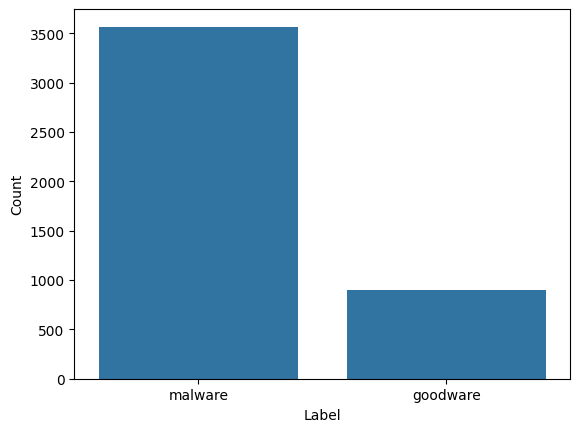

In [7]:
sns.countplot(x='Label', data=df)
plt.ylabel('Count')
df['Label'].value_counts(normalize=True)

## Pre-processing

In [8]:
# Split the features and target
X = df_encoded.drop(columns=['Label'])
y = df_encoded['Label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=seed, stratify=y)

# Oversample the train dataset
oversample = SMOTE(random_state=seed)
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [22]:
from xgboost import XGBClassifier

pipe1 = Pipeline([
    # ('umap', umap.UMAP(metric='hamming', n_jobs=-1)),
    ('clf', XGBClassifier(random_state=seed, 
                          eval_metric='logloss', n_jobs=-1))
])

search_space1 = {
    # 'umap__n_neighbors': Integer(5, 50),
    # 'umap__min_dist': Real(0.0, 0.9),
    # 'umap__n_components': Integer(2, 20),
    'clf__n_estimators': Integer(50, 500),
    'clf__max_depth': Integer(3, 15),
    'clf__learning_rate': Real(0.01, 0.3),
    'clf__subsample': Real(0.5, 1.0),
    'clf__colsample_bytree': Real(0.5, 1.0),
    # 'clf__gamma': Real(0.0, 5.0),
    # 'clf__reg_alpha': Real(0.0, 1.0),
    # 'clf__reg_lambda': Real(0.0, 1.0),
    # 'clf__scale_pos_weight': Real(1.0, 10.0), 
}

# Stratified K-Fold CV
kfoldcv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

opt1 = BayesSearchCV(
    pipe1,
    search_spaces=search_space1,
    n_iter=100,
    cv=kfoldcv,
    scoring='accuracy',
    random_state=seed,
    n_jobs=-1,
    verbose=2
)

opt1.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

BayesSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
              estimator=Pipeline(steps=[('clf',
                                         XGBClassifier(base_score=None,
                                                       booster=None,
                                                       callbacks=None,
                                                       colsample_bylevel=None,
                                                       colsample_bynode=None,
                                                       colsample_bytree=None,
                                                       device=None,
                                                       early_stopping_rounds=None,
                                                       enable_categorical=False,
                                                       eval_metric='logloss',
                                                       feature_types=None,
                                                       gamma=None,
                                                       gr...
              search_spaces={'clf__colsample_bytree': Real(low=0.5, high=1.0, prior='uniform', transform='normalize'),
                             'clf__learning_rate': Real(low=0.01, high=0.3, prior='uniform', transform='normalize'),
                             'clf__max_depth': Integer(low=3, high=15, prior='uniform', transform='normalize'),
                             'clf__n_estimators': Integer(low=50, high=500, prior='uniform', transform='normalize'),
                             'clf__subsample': Real(low=0.5, high=1.0, prior='uniform', transform='normalize')},
              verbose=2)

In [23]:
# Evaluate
print("Best hyperparameters:", opt1.best_params_)
print("Best CV accuracy:", opt1.best_score_)

Best hyperparameters: OrderedDict({'clf__colsample_bytree': 0.5192306821142503, 'clf__learning_rate': 0.29885082849153566, 'clf__max_depth': 15, 'clf__n_estimators': 495, 'clf__subsample': 0.562181334154009})
Best CV accuracy: 0.9929869151406123


In [24]:
# Accuracy and Confusion Matrix
print('XGB + BayesSearchCV')
print('Confusion Matrix')
y_test_pred1 = opt1.predict(X_test)
print(confusion_matrix(y_test, y_test_pred1))

# Classification Report
print(classification_report(y_test, y_test_pred1, target_names=['Goodware', 'Malware']))

XGB + BayesSearchCV
Confusion Matrix
[[178   2]
 [  0 713]]
              precision    recall  f1-score   support

    Goodware       1.00      0.99      0.99       180
     Malware       1.00      1.00      1.00       713

    accuracy                           1.00       893
   macro avg       1.00      0.99      1.00       893
weighted avg       1.00      1.00      1.00       893



In [25]:
from sklearn.inspection import permutation_importance

imp_xgb = permutation_importance(opt1, X_test, y_test, 
                                    random_state=seed, n_jobs=-1)

feature_names = X_test.columns
for i in imp_xgb.importances_mean.argsort()[::-1]:
    print(f"{feature_names[i]} - Importance: {imp_xgb.importances_mean[i]:.4f} ± {imp_xgb.importances_std[i]:.4f}")

RECEIVE_BOOT_COMPLETED - Importance: 0.0273 ± 0.0045
VIBRATE - Importance: 0.0184 ± 0.0027
SYSTEM_ALERT_WINDOW - Importance: 0.0130 ± 0.0029
Ljava/net/URL;->openConnection - Importance: 0.0099 ± 0.0008
Ljava/lang/Runtime;->exec - Importance: 0.0094 ± 0.0025
RECEIVE_SMS - Importance: 0.0047 ± 0.0008
WRITE_EXTERNAL_STORAGE - Importance: 0.0040 ± 0.0011
INTERNET - Importance: 0.0027 ± 0.0009
Ljava/lang/System;->load - Importance: 0.0022 ± 0.0007
WAKE_LOCK - Importance: 0.0022 ± 0.0012
WRITE_SETTINGS - Importance: 0.0020 ± 0.0008
Ljava/lang/reflect/Method;->invoke - Importance: 0.0018 ± 0.0009
BATTERY_STATS - Importance: 0.0016 ± 0.0005
KILL_BACKGROUND_PROCESSES - Importance: 0.0016 ± 0.0005
Landroid/telephony/TelephonyManager;->getLine1Number - Importance: 0.0013 ± 0.0004
BLUETOOTH - Importance: 0.0013 ± 0.0004
GET_TASKS - Importance: 0.0013 ± 0.0004
Ljavax/crypto/Cipher;->doFinal - Importance: 0.0013 ± 0.0008
Landroid/content/pm/PackageManager;->getInstalledPackages - Importance: 0.0011 

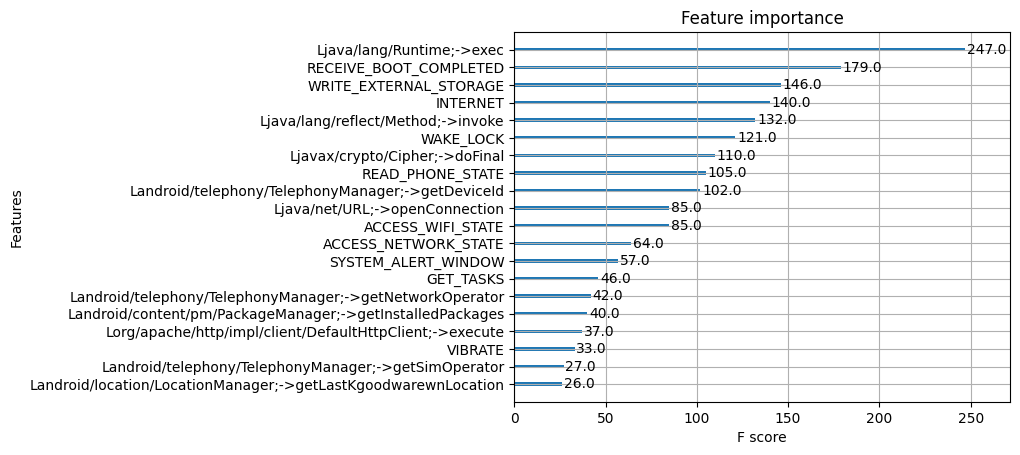

In [26]:
from xgboost import plot_importance

# Plot feature importance (default: weight)
clf1 = opt1.best_estimator_.named_steps['clf']
plot_importance(clf1, max_num_features=20)
plt.show()

In [27]:
# by gain
booster = clf1.get_booster()
importance = booster.get_score(importance_type='gain')

# Sort and display top features
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
for feature, score in sorted_importance[:10]:
    print(f"{feature}: {score}")


Ldalvik/system/DexClassLoader;->loadClass: 63.662330627441406
RECEIVE_BOOT_COMPLETED: 23.698171615600586
Ljava/net/URL;->openConnection: 17.885324478149414
Landroid/location/LocationManager;->getLastKgoodwarewnLocation: 16.27009391784668
Ljava/lang/System;->loadLibrary: 15.112419128417969
CHANGE_WIFI_STATE: 9.655970573425293
Landroid/telephony/TelephonyManager;->getSimOperatorName: 7.992552280426025
SEND_SMS: 7.328092575073242
VIBRATE: 7.115996360778809
GET_TASKS: 6.59700870513916


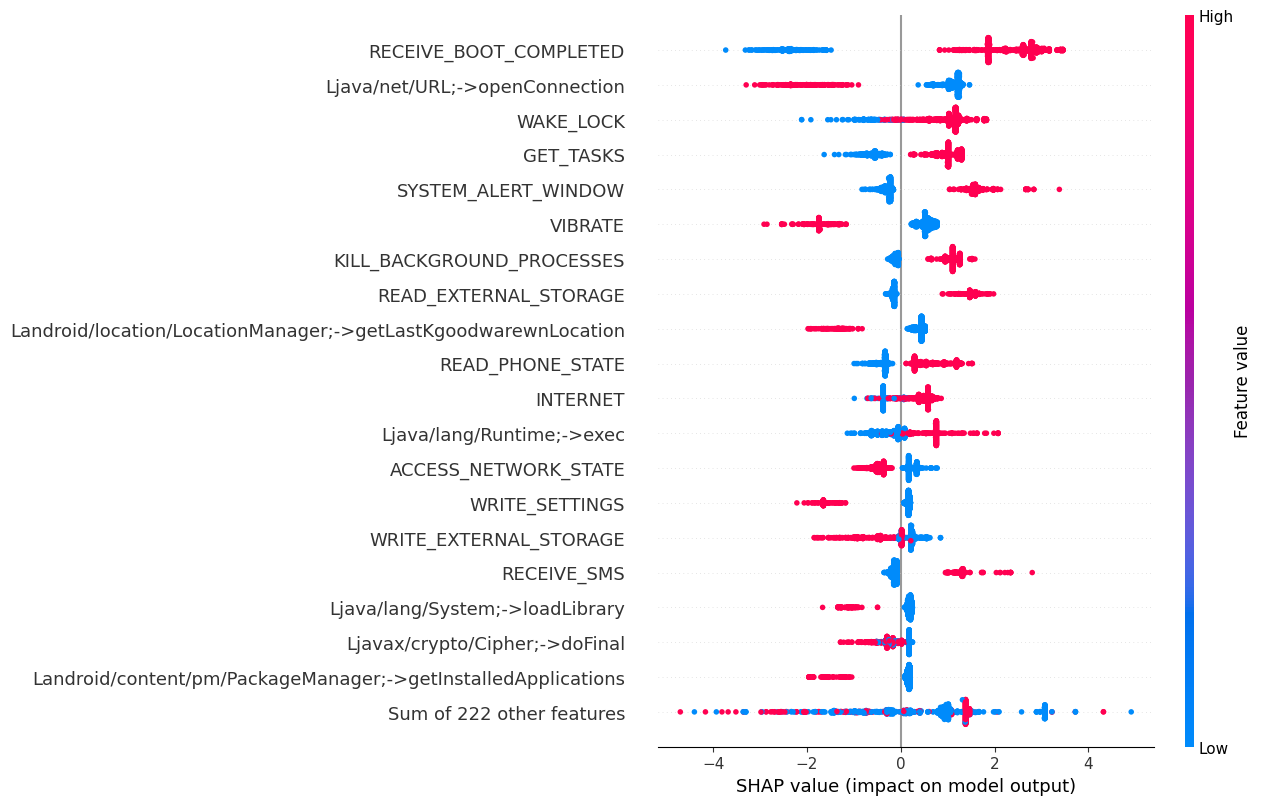

In [28]:
# shap
import shap

explainer = shap.Explainer(clf1)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=20)  # Summary of global importance